<h1 align="center">
<img src="https://github.com/user-attachments/assets/8e8f207e-b234-475e-af6e-b7ea5f182c5f" alt="ReadMe" width="700">

<img src="https://github.com/user-attachments/assets/a729c62f-b909-4c85-b0cf-c51809e05e01" alt="ReadMe" width="700">
</h1>

# UNet - Segmentation

## 1- Import libraries

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, ToTensor, Resize

import torchmetrics
from torchmetrics.classification import BinaryAccuracy
import albumentations as A
from albumentations.pytorch import ToTensorV2 # np.array -> torch.tensor
import os
from tqdm import tqdm
from glob import glob
import argparse
import torch.optim as optim
from torch import optim, nn
from torchmetrics.segmentation import GeneralizedDiceScore, MeanIoU
import time
import random
import warnings
from PIL import Image

warnings.filterwarnings("ignore")


/opt/miniconda3/envs/deeplearn_course/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 2- Custom Dataset

In [ ]:
class PetDataset(Dataset):
    def __init__(self, root="kaggle/input/the-oxfordiiit-pet-dataset", is_train=True, transform=None):
        """
        Initialize the PetDataset.

        Parameters:
        - root: str, the root directory of the dataset.
        - is_train: bool, determines whether to use training or testing annotations.
        - transform: callable, optional transform to be applied on a sample.
        """
        self.transform = transform
        self.classes = ['background', 'animal']
        self.root = root
        
        # Select the appropriate annotation file based on whether it's training or testing
        if is_train:
            annotations = os.path.join(root, "annotations","trainval.txt")
        else:
            annotations = os.path.join(root, "annotations", "test.txt")
        
        # Read the annotation file and extract image names
        with open(annotations, 'r') as file:
            self.img_names = [image.split(' ')[0] for image in file.readlines()]
    
    def __len__(self):
        """
        Return the total number of images in the dataset.
        """
        return len(self.img_names)

    def __getitem__(self, item):
        """
        Retrieve an image and its corresponding mask by index.
        
        Parameters:
        - item: int, index of the image to retrieve.
        
        Returns:
        - image: np.array, the image data.
        - mask: np.array, the mask data.
        """
        # Get the image name and construct the paths to the image and mask files
        img_name = self.img_names[item]
        img_path = os.path.join(self.root, "images",  img_name) + ".jpg"
        mask_path = os.path.join(self.root, "annotations",  "trimaps", img_name) + ".png"

        # Read the image and convert it from BGR to RGB
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Read the mask and adjust its values
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) #0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue.
        mask[mask == 2] = 0  # Set background class to 0
        mask[mask == 3] = 1  # Set animal class to 1
        
        # Apply transformations if provided
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        
        return image, mask


mask shape: (500, 375)
mask unique:  [0 1]


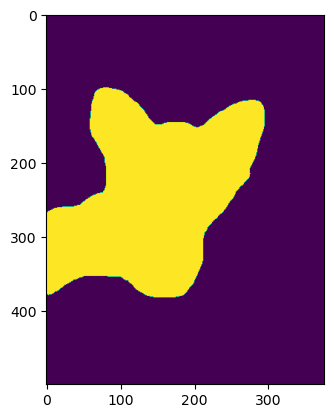

In [3]:
petdataset = PetDataset()
img, mask = petdataset[10]
print("mask shape:", mask.shape)
print("mask unique: ",np.unique(mask))
plt.imshow(mask)

In [4]:
def run_comprehensive_eda(dataset_path="/kaggle/input/the-oxfordiiit-pet-dataset"):
    print(">>> Running comprehensive Exploratory Data Analysis (EDA)...")
    
    # Initialize a base dataset without transforms for statistical purposes
    base_dataset = PetDataset(root=dataset_path, is_train=True, transform=None)
    
    # Randomly sample 50 items for global statistics (to avoid excessive time computing the whole dataset)
    subset_size = min(50, len(base_dataset))
    sample_indices = random.sample(range(len(base_dataset)), subset_size)
    
    heights, widths = [], []
    bg_pixels, fg_pixels = 0, 0
    
    for idx in sample_indices:
        img, mask = base_dataset[idx]
        heights.append(img.shape[0])
        widths.append(img.shape[1])
        bg_pixels += np.sum(mask == 0)
        fg_pixels += np.sum(mask == 1)

    # Define an augmentation pipeline for preview (excluding ToTensorV2 for direct matplotlib plotting)
    demo_transform = A.Compose([
        A.Resize(width=224, height=224),
        A.HorizontalFlip(p=1.0),            # Force flip to see effect
        A.RandomBrightnessContrast(p=1.0),  # Force brightness/contrast change
        A.RGBShift(p=1.0),
    ])

    # Randomly select an image to demonstrate details and augmentation
    demo_idx = random.choice(sample_indices)
    demo_img, demo_mask = base_dataset[demo_idx]
    augmented = demo_transform(image=demo_img, mask=demo_mask)
    aug_img, aug_mask = augmented['image'], augmented['mask']

    # --- Start drawing the 2x2 comprehensive dashboard ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle("Oxford-IIIT Pet Dataset EDA & Augmentation Preview", fontsize=16)

    # [1] Sample Image & Mask Overlay
    axes[0, 0].imshow(demo_img)
    axes[0, 0].imshow(demo_mask, cmap='jet', alpha=0.4) # Overlay semi-transparent mask using pseudocolor
    axes[0, 0].set_title(f"Sample & Mask Overlay (Index: {demo_idx})")
    axes[0, 0].axis('off')

    # [2] Class distribution statistics (pixel-level)
    labels = ['Background (Class 0)', 'Animal (Class 1)']
    counts = [bg_pixels, fg_pixels]
    axes[0, 1].bar(labels, counts, color=['#A9A9A9', '#FF8C00'])
    axes[0, 1].set_title(f"Pixel Class Distribution (Sampled {subset_size} images)")
    axes[0, 1].set_ylabel("Total Pixels")
    
    # Display proportions on the bars
    total_pixels = bg_pixels + fg_pixels
    axes[0, 1].text(0, bg_pixels, f"{bg_pixels/total_pixels:.1%}", ha='center', va='bottom')
    axes[0, 1].text(1, fg_pixels, f"{fg_pixels/total_pixels:.1%}", ha='center', va='bottom')

    # [3] Image size distribution analysis (scatter plot)
    axes[1, 0].scatter(widths, heights, alpha=0.6, edgecolors='w', s=80)
    axes[1, 0].set_title("Image Resolution Distribution (W vs H)")
    axes[1, 0].set_xlabel("Width (Pixels)")
    axes[1, 0].set_ylabel("Height (Pixels)")
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)

    # [4] Data augmentation effect preview
    axes[1, 1].imshow(aug_img)
    axes[1, 1].set_title("Augmentation Preview (Resize, Flip, Brightness, RGB Shift)")
    axes[1, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    print(">>> EDA completed.\n")

>>> Running comprehensive Exploratory Data Analysis (EDA)...


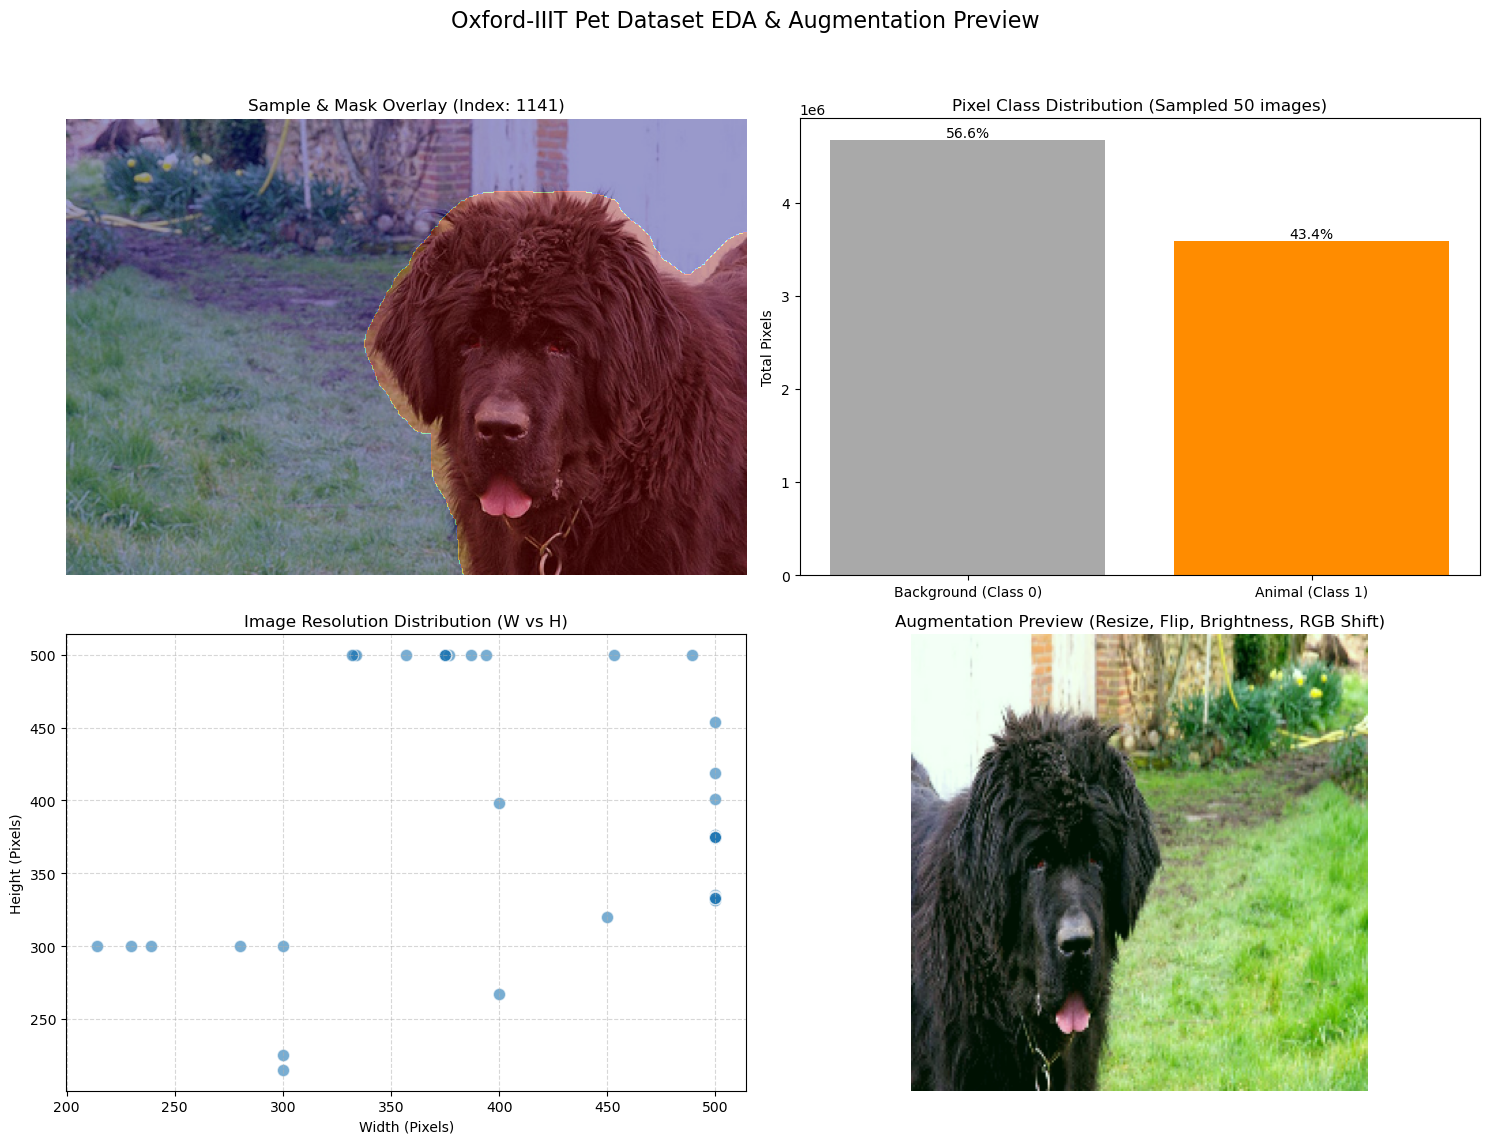

>>> EDA completed.



In [7]:
run_comprehensive_eda("kaggle/input/the-oxfordiiit-pet-dataset")

## 3- Build Model

In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Double convolution layer with ReLU activation.
        
        Parameters:
        - in_channels: int, number of input channels.
        - out_channels: int, number of output channels.
        """
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)

class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Downsampling layer with double convolution and max pooling.
        
        Parameters:
        - in_channels: int, number of input channels.
        - out_channels: int, number of output channels.
        """
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)
        return down, p

class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Upsampling layer with transpose convolution and double convolution.
        
        Parameters:
        - in_channels: int, number of input channels.
        - out_channels: int, number of output channels.
        """
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x1, x2], 1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        """
        UNet architecture for image segmentation.
        
        Parameters:
        - in_channels: int, number of input channels.
        - num_classes: int, number of output classes.
        """
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)

        self.bottle_neck = DoubleConv(512, 1024)

        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)
        
        self.out = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)

    def forward(self, x):

        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4)

        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)

        out = self.out(up_4)
        return out


## 4- Train Unet Model

In [ ]:
def train():
    # Hyperparameters and paths
    LEARNING_RATE = 0.0001
    BATCH_SIZE = 10
    EPOCHS = 50
    NUM_WORKERS = 4
    DATA_PATH = "data"
    MODEL_SAVE_PATH = "kaggle/working/models"
    
    # Create model save directory if it doesn't exist
    if not os.path.isdir(MODEL_SAVE_PATH):
        os.mkdir(MODEL_SAVE_PATH)
    
    # Data augmentation and preprocessing for training and testing
    train_transform = A.Compose([
        A.Resize(width=224, height=224),
        A.HorizontalFlip(),
        A.RandomBrightnessContrast(),
        A.Blur(),
        A.Sharpen(),
        A.RGBShift(),
        ToTensorV2(),
    ])

    test_transform = A.Compose([
        A.Resize(width=224, height=224),
        ToTensorV2(),
    ])
    
    # Create datasets and dataloaders
    train_dataset = PetDataset("kaggle/input/the-oxfordiiit-pet-dataset", is_train=True, transform=train_transform)
    val_dataset = PetDataset("kaggle/input/the-oxfordiiit-pet-dataset", is_train=False, transform=test_transform)

    train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True, drop_last=True)
    val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False, drop_last=True)
    
    # Load model and move it to the appropriate device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet(in_channels=3, num_classes=1)
    model.to(device)
    
    # Initialize optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.BCEWithLogitsLoss()
    # Metrics
    miou_metric = MeanIoU(num_classes=2)
    dice_metric = GeneralizedDiceScore(num_classes=2)
    
    # Best validation IoU for saving the best model
    best_predict = -1
    current_epoch = 0
    
    # Training loop
    for epoch in range(current_epoch,EPOCHS+1):
        #Phase training
        model.train()
        train_progress= tqdm(train_dataloader, colour="cyan")
        for idx, img_mask in enumerate(train_progress):
            img = img_mask[0].float().to(device) #img - B,C,H,W
            mask = img_mask[1].float().to(device) #label - B,H,W
            
            y_pred = model(img) #B,1, H, W
            y_pred = y_pred.squeeze() #B H W
            optimizer.zero_grad()

            loss = criterion(y_pred, mask) 
            
            loss.backward()
            optimizer.step()
            train_progress.set_description("TRAIN| Epoch: {}/{}| Loss: {:0.4f}".format(epoch, EPOCHS,loss))

        #Phase evaluation
        model.eval()
        all_losses = []
        all_ious = []
        all_dices = []
        
        with torch.no_grad():
            for idx, img_mask in enumerate(val_dataloader):
                img = img_mask[0].float().to(device)
                mask = img_mask[1].float().to(device) #B W H

                y_pred = model(img)
                y_pred = y_pred.squeeze() #B H W
                
                loss = criterion(y_pred, mask)
                
                mask = mask.long().cpu()
                y_pred[y_pred>0]=1 #BWH
                y_pred[y_pred<0]=0 #BWH
                y_pred = y_pred.long().cpu()
            
                miou = miou_metric(y_pred, mask)
                dice = dice_metric(y_pred, mask)

                all_losses.append(loss.cpu().item())
                all_ious.append(miou.cpu().item())
                all_dices.append(dice.cpu().item())
                if idx == 40: break
    
        # Compute mean IoU for the epoch
        loss = np.mean(all_losses)
        miou = np.mean(all_ious)
        dice = np.mean(all_dices)
    
        print("VAL| Loss: {:0.4f} | mIOU: {:0.4f} | Dice: {:0.4f}".format(
                loss, miou, dice))
        
        # Create checkpoint
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "epoch": epoch, 
            "optimizer_state_dict": optimizer.state_dict(),
            "miou": miou
        }
        
        # Save last checkpoint
        torch.save(checkpoint, os.path.join(MODEL_SAVE_PATH, "last.h5"))
        
        # Save best checkpoint based on IoU
        if miou > best_predict:
            torch.save(checkpoint, os.path.join(MODEL_SAVE_PATH, "best.h5"))
            best_predict = miou


In [19]:
if __name__ == '__main__':
    train()
    #pass

TRAIN| Epoch: 0/50| Loss: 0.7554:   2%|▏         | 9/368 [03:01<2:00:34, 20.15s/it]Corrupt JPEG data: premature end of data segment
TRAIN| Epoch: 0/50| Loss: 0.6576:   3%|▎         | 11/368 [04:12<2:16:43, 22.98s/it]


KeyboardInterrupt: 

![image](https://github.com/user-attachments/assets/f7d19ee7-3b0b-444d-879e-64996adc182c)

In [7]:
# !zip -r best.zip /kaggle/working/models/best.h5

### Results after training for 50 epochs:
- Loss: 0.3
- mIOU: 0.65
- Dice: 0.71

## 5- Inference

In [8]:
def pred_show_image_grid(model_pth, device, transform):
    
    checkpoint = torch.load(model_pth)
    model = UNet(in_channels=3, num_classes=1)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    
    image_dataset = PetDataset(is_train=True, transform=transform)
    
    images = []
    orig_masks = []
    pred_masks = []

    for idx,(img, orig_mask) in enumerate(image_dataset):
        images.append(img.permute(1, 2, 0))
        
        img = img.float().to(device)
        img = img.unsqueeze(0)

        pred_mask = model(img)

        img = img.squeeze(0).cpu().detach()
        img = img.permute(1, 2, 0)

        pred_mask = pred_mask.squeeze(0).cpu().detach()
        pred_mask = pred_mask.permute(1, 2, 0)
        pred_mask[pred_mask < 0]=0
        pred_mask[pred_mask > 0]=1

        
        orig_mask = orig_mask.cpu().detach()
        orig_masks.append(orig_mask)
        pred_masks.append(pred_mask)
        if idx==5: break
            
    images.extend(orig_masks)
    images.extend(pred_masks)
    fig = plt.figure(figsize=(15,8))
    for i in range(1, 3*6+1):
       fig.add_subplot(3, 6, i)
       plt.imshow(images[i-1], cmap="gray")


In [9]:
test_trainsform = A.Compose([
        A.Resize(width=224, height=224),
        ToTensorV2(),
    ])

MODEL_PATH = "/kaggle/working/models/best.h5"

device = "cuda" if torch.cuda.is_available() else "cpu"
# pred_show_image_grid(model_pth= MODEL_PATH, device= device, transform= test_trainsform)


## Results after training for 50 epochs:

<h4 align="center">
    <img src="https://github.com/user-attachments/assets/fc401fc8-1d24-4c0c-807c-b9112d5b943b" >
</h4>

<h4 align="center">
    <img src="https://github.com/user-attachments/assets/cc65eb41-8a57-458c-82b7-ab5a4e0b11e4" alt="ReadMe" width="600">
</h4>